<a href="https://colab.research.google.com/github/gautam1218/Data-Science/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Finaance Data mini project

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('financial_loan.xlsx')
df.head()


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [ ]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [ ]:
#count total number of alpplication
number_of_appl = df['id'].nunique()
print(f'Total number of application is {number_of_appl}')

# df.id.unique().size

Total number of application is 38576


In [ ]:

#number of application in current month
current_date = pd.Timestamp.today()
current_month = current_date.month
current_day = current_date.day

appl_in_current_month = df[(df['issue_date'].dt.month == current_month) & (df['issue_date'].dt.day <= current_day)]
number_of_appl_in_current_month = appl_in_current_month['id'].nunique()
print(f'Total number of application in current month is {number_of_appl_in_current_month}')

Total number of application in current month is 3184


In [ ]:
#calculation loan_amount to current date
current_date = pd.Timestamp.today()
current_month = current_date.month
current_day = current_date.day

loans_in_current_month = df[(df['issue_date'].dt.month == current_month) & (df['issue_date'].dt.day <= current_day)]
total_loan_amount_current_month = loans_in_current_month['loan_amount'].sum()
print(f'Total loan amount for applications in the current month in million is : $ {(total_loan_amount_current_month)/1000000} milions')

Total loan amount for applications in the current month in million is : $ 34.161475 milions


In [ ]:
# determining Good loan metrices and Bad laon Matrices
#good loan is fully paid and current loan
#bad loan is when loan is charged



From this summary, you can clearly see the 'Fully Paid' and 'Current' statuses contributing to 'Good Loans', and 'Charged Off' for 'Bad Loans'.

In [ ]:
loan_status_data = df.groupby('loan_status').agg({
    'id': 'count',
    'dti':'mean',
    'int_rate':'mean',
    'loan_amount': 'sum',
    'total_payment': 'sum'
})

loan_status_data.rename(columns={'id': 'Number of application'}, inplace=True)
display(loan_status_data)

#number off good loan application, good loan is defined as fully paid and current of loan_status
#number of bad laon


,Number of application,dti,int_rate,loan_amount,total_payment
loan_status,,,,,
Charged Off,5333,0.140047,0.138786,65532225,37284763
Current,1098,0.147243,0.150993,18866500,24199914
Fully Paid,32145,0.131674,0.116411,351358350,411586256


In [ ]:
# Calculate the number of good loan applications
good_loan_applications = loan_status_data.loc[['Fully Paid', 'Current'], 'Number of application'].sum()

# Calculate the number of bad loan applications
bad_loan_applications = loan_status_data.loc['Charged Off', 'Number of application']

print(f'Number of Good Loan Applications: {good_loan_applications}')
print(f'Number of Bad Loan Applications: {bad_loan_applications}')

Number of Good Loan Applications: 33243
Number of Bad Loan Applications: 5333


In [ ]:
#good loan funded amount, Bad loan fundend amount
good_loan_funded_amount = loan_status_data.loc[['Fully Paid', 'Current'], 'loan_amount'].sum()
bad_loan_funded_amount = loan_status_data.loc['Charged Off', 'loan_amount'].sum()
print("Good loan amount :",good_loan_funded_amount)
print("Bad loan amount :",bad_loan_funded_amount)

Good loan amount : 370224850
Bad loan amount : 65532225


In [ ]:
#draw graph betweeen fiding the month  by issued_date vs loan_amount



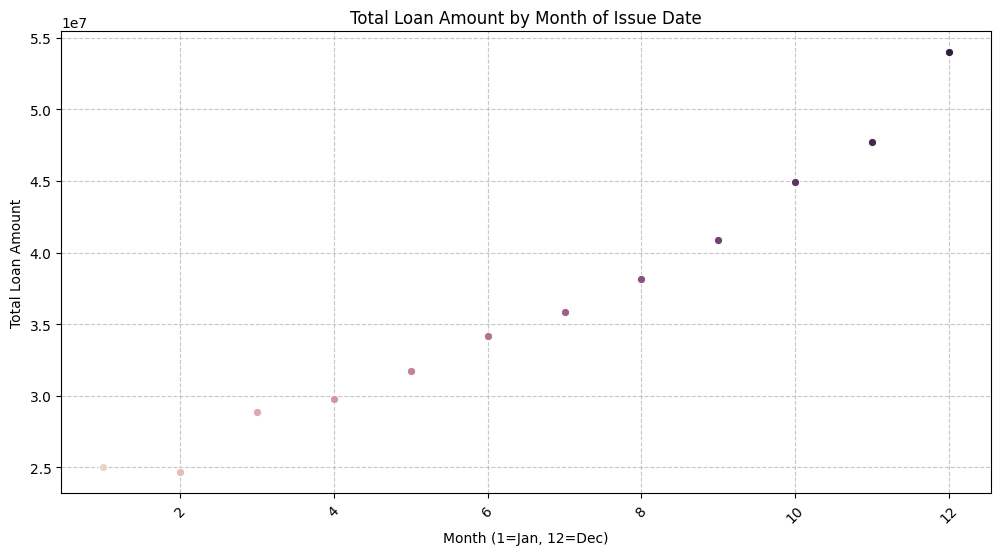

In [ ]:
df['issue_month'] = df['issue_date'].dt.month
monthly_loan_amount = df.groupby('issue_month')['loan_amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='issue_month', y='loan_amount', data=monthly_loan_amount, marker='o', hue='issue_month', legend=False)
plt.title('Total Loan Amount by Month of Issue Date')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Total Loan Amount')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

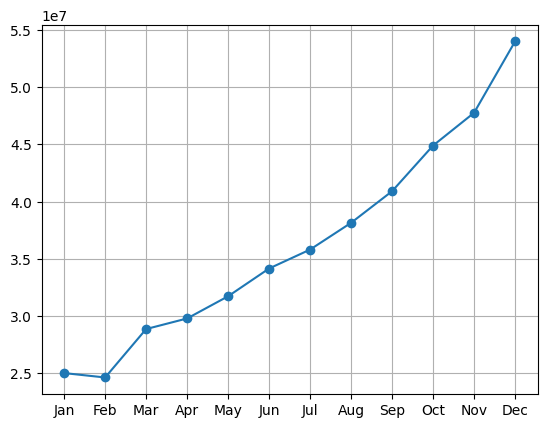

In [ ]:
df['month'] = df['issue_date'].dt.month
new_df = df.groupby('month',as_index=False)['loan_amount'].sum()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(months,new_df['loan_amount'],marker='o')
# plt.show()
plt.grid()